In [ ]:
print("Hello_testing_yaswanh")

In [ ]:
!pip install openai-agents

In [ ]:
!pip install openai-agents python-dotenv

In [ ]:
!pip install dotenv

In [ ]:
!pip install agents

In [ ]:
!python First_AI_agent.py

In [ ]:
import asyncio
import os

from dotenv import load_dotenv
from agents import Agent, Runner

# Load variables from .env
load_dotenv()

# Verify the key exists WITHOUT displaying it
if not os.getenv("OPENAI_API_KEY"):
    raise RuntimeError("OPENAI_API_KEY was not found.")

agent = Agent(
    name="Network Engineer Assistant",

    instructions="""
    You are an AI assistant for a network engineer.

    Help the user understand:
    - TCP/IP
    - BGP
    - OSPF
    - IS-IS
    - VLANs
    - MPLS
    - Cisco
    - Juniper
    - Arista
    - Azure Networking
    - Python network automation

    Explain technical concepts clearly and provide examples
    when useful.
    """,
)


async def main():
    question = input("Ask the AI agent: ")

    result = await Runner.run(
        agent,
        question,
    )

    print("\nAI Agent:")
    print(result.final_output)


if __name__ == "__main__":
    asyncio.run(main())

The API key is loading now. The new error is unrelated to the key.

Your error is:

```text
RuntimeError: asyncio.run() cannot be called from a running event loop
```

That happens because you are running the code inside a **Jupyter notebook (`.ipynb`)**. Jupyter already has an async event loop running, so this:

```python
asyncio.run(main())
```

must not be used there.

Replace this:

```python
if __name__ == "__main__":
    asyncio.run(main())
```

with simply:

```python
await main()
```

So the bottom of your notebook should be:

```python
async def main():
    question = input("Ask the AI agent: ")

    result = await Runner.run(
        agent,
        question,
    )

    print("\nAI Agent:")
    print(result.final_output)


await main()
```

Or even simpler, for a notebook you don't actually need `main()`:

```python
question = input("Ask the AI agent: ")

result = await Runner.run(
    agent,
    question
)

print("\nAI Agent:")
print(result.final_output)
```

Then run the cell again. You should get:

```text
Ask the AI agent:
```

and you can enter something like:

```text
Explain BGP and give me a Cisco configuration example
```

### Important: your API key is exposed

In your second screenshot, the **actual API key is visible on the screen**. Because that screenshot was shared, you should consider that key compromised.

**Do not continue using that key. Revoke it and create a new one.**

After creating the replacement, keep your `.env` like this:

```text
OPENAI_API_KEY=your_new_key
```

Never open the `.env` file when taking screenshots, and never print the variable:

```python
# DON'T do this
print(os.getenv("OPENAI_API_KEY"))
```

Checking it safely is fine:

```python
if os.getenv("OPENAI_API_KEY"):
    print("API key loaded successfully")
```

Also make sure your `.gitignore` contains:

```text
.env
*.env
.venv/
__pycache__/
```

Your immediate code fix is therefore:

```text
Jupyter Notebook
      ↓
already running async loop
      ↓
asyncio.run(main())   ❌
      ↓
await main()          ✅
      ↓
Runner.run()
      ↓
Your AI Agent
```

After replacing `asyncio.run(main())` with `await main()`, run it again.


In [ ]:
import os

from dotenv import load_dotenv
from agents import Agent, Runner


# Load API key from .env
load_dotenv()


# Check whether the API key exists without displaying it
if not os.getenv("OPENAI_API_KEY"):
    raise RuntimeError("OPENAI_API_KEY was not found.")

print("API key loaded successfully.")


# Create the AI agent
agent = Agent(
    name="Network Engineer Assistant",

    instructions="""
    You are an AI assistant for a network engineer.

    Help the user understand and troubleshoot topics such as:

    - TCP/IP
    - BGP
    - OSPF
    - IS-IS
    - VLANs
    - MPLS
    - Cisco IOS and IOS XR
    - Juniper Junos
    - Arista EOS
    - Azure Networking
    - Python network automation

    Explain technical concepts clearly.

    When appropriate:
    - provide configuration examples
    - provide troubleshooting steps
    - explain commands line by line
    - provide Python examples
    - compare technologies using simple examples

    Keep answers practical and useful for a network engineer.
    """
)


# Ask the user a question
question = input("Ask the AI agent: ")


# Run the agent
result = await Runner.run(
    agent,
    question
)


# Display the response
print("\nAI Agent:")
print(result.final_output)

In [ ]:
!python agent.py

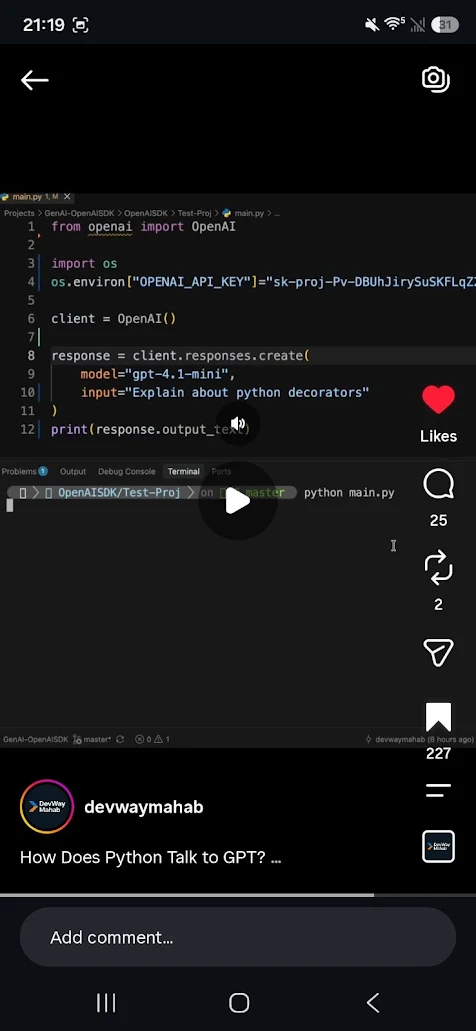

In [ ]:
from openai import OpenAI
import os

# Put your API key directly here
os.environ["OPENAI_API_KEY"] = "sk-proj"

client = OpenAI()

response = client.responses.create(
    model="gpt-5",
    input="Explain Python decorators"
)

print(response.output_text)